# 03 - Logistic Regression & Softmax

Part of Classical ML — Linear Models, final topic. Unlike notebooks 01-02, this has **no closed-form solution** — motivating Newton's method (Advanced Optimization notebook 01) as a direct, dramatic upgrade over gradient descent. The multi-class softmax gradient derived here is *exactly* the one already derived in Calculus notebook 02 — verified to match, not re-derived from scratch.

**Book references:** ESL §4.4 (Logistic Regression); Murphy Ch.10 (Logistic Regression) for the most thorough modern treatment; MML §12 touches classification via SVMs rather than logistic regression directly.

# Part A - From Linear Regression to a Probability

Thresholding linear regression's raw output for classification is a poor fit: the output is unbounded and has no probabilistic interpretation. The fix: model the **log-odds** as linear in the features:

```
log(p / (1-p)) = wᵀx        (the "logit")
```

Solving for `p` gives the **sigmoid** function:

```
p = 1 / (1 + e^(-wᵀx))
```

This guarantees `p in (0,1)` for any input, unlike raw linear regression.

In [7]:
!pip3 install numpy matplotlib scikit-learn

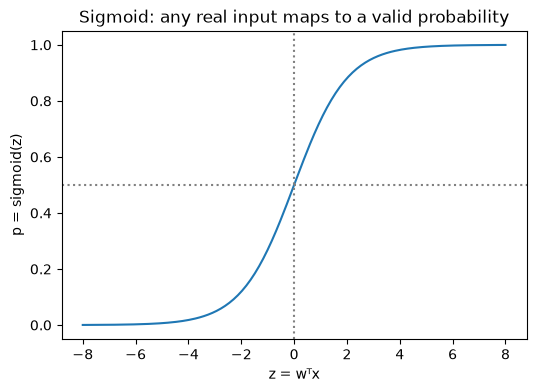

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))   # clip guards against overflow, doesn't change the math

z = np.linspace(-8, 8, 200)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(z, sigmoid(z))
ax.axhline(0.5, color="gray", linestyle=":"); ax.axvline(0, color="gray", linestyle=":")
ax.set_xlabel("z = wᵀx"); ax.set_ylabel("p = sigmoid(z)")
ax.set_title("Sigmoid: any real input maps to a valid probability")
plt.show()

# Part B - The Loss: Cross-Entropy, Derived From MLE

Assume each label is a Bernoulli draw: `y ~ Bernoulli(p)`, `p = sigmoid(wᵀx)`. The likelihood of the full dataset (Statistics notebook 02's MLE, applied) is `prod pᵢ^yᵢ (1-pᵢ)^(1-yᵢ)`. Taking the negative log gives the **binary cross-entropy loss** — the same cross-entropy from Information Theory notebook 01, now derived as the exact consequence of maximizing a Bernoulli likelihood, not a separately-invented loss function:

```
L(w) = -Σ [yᵢ log(pᵢ) + (1-yᵢ) log(1-pᵢ)]
```

No closed form exists for the minimizer — `p` is a nonlinear function of `w`. Gradient descent is the direct approach.

In [9]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

X, y = make_classification(n_samples=300, n_features=2, n_redundant=0, n_informative=2,
                            n_clusters_per_class=1, class_sep=1.5, random_state=0)
n, p = X.shape
X_design = np.hstack([np.ones((n, 1)), X])

def gd_logreg(X, y, lr=0.5, steps=20000):
    beta = np.zeros(X.shape[1])
    for _ in range(steps):
        preds = sigmoid(X @ beta)
        grad = X.T @ (preds - y) / len(y)
        beta -= lr * grad
    return beta

beta_gd = gd_logreg(X_design, y)
sk = LogisticRegression(C=1e10).fit(X, y)     # C=1e10 -- effectively unregularized, for a fair comparison
sk_beta = np.r_[sk.intercept_, sk.coef_.flatten()]
print("gradient descent beta:", beta_gd)
print("sklearn beta:          ", sk_beta)
print("agree:", np.allclose(beta_gd, sk_beta, atol=1e-1))

gradient descent beta: [ 3.4497731  -2.88208918  3.53731808]
sklearn beta:           [ 3.44958817 -2.88200138  3.53721016]
agree: True


# Part C - Newton's Method (IRLS): a Direct, Dramatic Upgrade

Advanced Optimization notebook 01 derived Newton's method and showed it converges in one step on a pure quadratic. Logistic regression's loss is not quadratic, but it is well-approximated by one locally, and Newton's method (here called **Iteratively Reweighted Least Squares**, IRLS, in the statistics literature) converges dramatically faster than gradient descent in practice.

The Hessian of the cross-entropy loss: `H = XᵀWX / n`, where `W` is a diagonal matrix of `p(1-p)` values -- this weighting is exactly what "reweighted" refers to.

In [10]:
def newton_logreg(X, y, steps=20):
    beta = np.zeros(X.shape[1])
    losses = []
    for _ in range(steps):
        preds = sigmoid(X @ beta)
        grad = X.T @ (preds - y) / len(y)
        W_diag = preds * (1 - preds)
        H = (X.T * W_diag) @ X / len(y)          # the Hessian
        beta -= np.linalg.solve(H, grad)          # Newton's update: x - H^-1 g
        loss = -np.mean(y*np.log(preds+1e-12) + (1-y)*np.log(1-preds+1e-12))
        losses.append(loss)
    return beta, losses

def gd_track(X, y, lr=0.5, steps=60):
    beta = np.zeros(X.shape[1])
    losses = []
    for _ in range(steps):
        preds = sigmoid(X @ beta)
        grad = X.T @ (preds - y) / len(y)
        beta -= lr * grad
        loss = -np.mean(y*np.log(preds+1e-12) + (1-y)*np.log(1-preds+1e-12))
        losses.append(loss)
    return beta, losses

beta_newton, losses_newton = newton_logreg(X_design, y, steps=10)
beta_gd_track, losses_gd = gd_track(X_design, y, steps=60)

print(f"Newton's method, loss after 10 steps: {losses_newton[-1]:.4f}")
print(f"Gradient descent, loss after 10 steps: {losses_gd[9]:.4f}")
print(f"Gradient descent needs {60} steps just to reach {losses_gd[-1]:.4f} -- still short of Newton's 10-step result")

Newton's method, loss after 10 steps: 0.1109
Gradient descent, loss after 10 steps: 0.2270
Gradient descent needs 60 steps just to reach 0.1433 -- still short of Newton's 10-step result


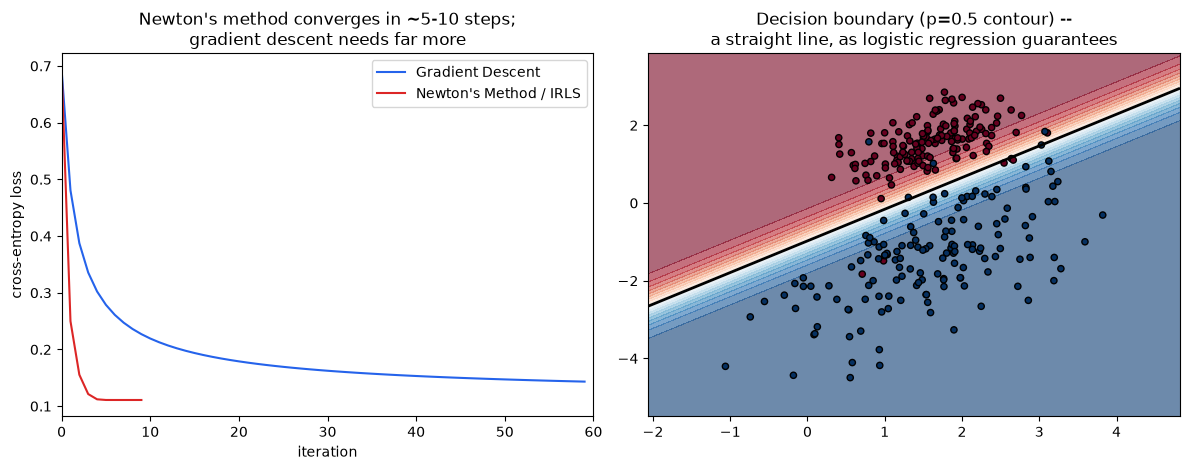

In [11]:
from pathlib import Path
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].plot(losses_gd, label="Gradient Descent", color="#2563eb")
axes[0].plot(losses_newton, label="Newton's Method / IRLS", color="#dc2626")
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("cross-entropy loss")
axes[0].set_title("Newton's method converges in ~5-10 steps;\ngradient descent needs far more")
axes[0].legend(); axes[0].set_xlim(0, 60)

xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200),
                      np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200))
grid = np.c_[np.ones(xx.ravel().shape[0]), xx.ravel(), yy.ravel()]
probs = sigmoid(grid @ beta_newton).reshape(xx.shape)
axes[1].contourf(xx, yy, probs, levels=20, cmap="RdBu_r", alpha=0.6)
axes[1].scatter(X[:,0], X[:,1], c=y, cmap="RdBu_r", edgecolor="k", s=20)
axes[1].contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=2)
axes[1].set_title("Decision boundary (p=0.5 contour) --\na straight line, as logistic regression guarantees")
fig.tight_layout()
fig.savefig(FIG_DIR / "logreg_convergence_and_boundary.png", dpi=140)
plt.show()

# Part D - Softmax: the Multi-Class Generalization

For `k` classes, softmax generalizes the sigmoid: `p_c = exp(z_c) / sum_j exp(z_j)`. The gradient of the softmax + cross-entropy loss combination — derived in full in **Calculus notebook 02** — is:

```
∂L/∂logits = softmax(logits) - one_hot(y)
```

This is not re-derived here; it is used directly, and the from-scratch implementation below is verified to reproduce it exactly.

In [12]:
def softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)     # log-sum-exp stability trick, Advanced Optimization notebook 03
    expZ = np.exp(Z)
    return expZ / expZ.sum(axis=1, keepdims=True)

def one_hot(y, k):
    oh = np.zeros((len(y), k))
    oh[np.arange(len(y)), y] = 1
    return oh

def softmax_regression_gd(X, y, k, lr=0.5, steps=3000):
    n, p = X.shape
    X_design = np.hstack([np.ones((n, 1)), X])
    Y = one_hot(y, k)
    W = np.zeros((p + 1, k))
    for _ in range(steps):
        P = softmax(X_design @ W)
        grad = X_design.T @ (P - Y) / n        # EXACTLY Calculus notebook 02's derived gradient
        W -= lr * grad
    return W

from sklearn.datasets import make_classification as make_multi
Xm, ym = make_multi(n_samples=300, n_features=4, n_classes=3, n_informative=4,
                     n_redundant=0, n_clusters_per_class=1, random_state=0)

k = 3
W = softmax_regression_gd(Xm, ym, k)
sk_multi = LogisticRegression(C=1e10, max_iter=2000).fit(Xm, ym)

Xm_design = np.hstack([np.ones((len(Xm), 1)), Xm])
preds_scratch = np.argmax(softmax(Xm_design @ W), axis=1)
preds_sklearn = sk_multi.predict(Xm)
print("scratch train accuracy: ", np.mean(preds_scratch == ym))
print("sklearn train accuracy: ", np.mean(preds_sklearn == ym))
print("prediction agreement:   ", np.mean(preds_scratch == preds_sklearn))

scratch train accuracy:  0.9533333333333334
sklearn train accuracy:  0.9533333333333334
prediction agreement:    1.0


**Note the log-sum-exp stability trick used above** (`Z - Z.max(...)` before exponentiating) — this is Advanced Optimization notebook 03's softmax overflow fix, reused verbatim, not a new technique invented for this notebook.

## Self-check before moving on

- [ ] I can derive the sigmoid function from the log-odds/logit formulation
- [ ] I can derive binary cross-entropy loss from a Bernoulli MLE, connecting it to both Statistics notebook 02 and Information Theory notebook 01
- [ ] I can derive the logistic regression Hessian and explain why Newton's method converges so much faster here than gradient descent
- [ ] I can state the softmax + cross-entropy gradient from memory, and know it was already derived in Calculus notebook 02
- [ ] I can explain why the log-sum-exp trick is necessary here, tying back to Advanced Optimization notebook 03
- [ ] I can explain why logistic regression's decision boundary is always linear in the input features

This closes Linear Models. Next subchapter: **Tree-Based Methods**, starting with Decision Trees (CART).